# Crop Recommendation System — Main Pipeline

This notebook is the **orchestrator**. It imports and calls the preprocessing modules and loads the trained model.

```
main.ipynb
    │
    ├── Notebooks/display_raw_data.ipynb
    ├── Preprocessing/duplicate_values.py
    ├── Preprocessing/missing_values.py
    ├── Preprocessing/eda_correlation.py
    ├── Preprocessing/export_processed_data.py
    ├── Notebooks/display_processed_data.ipynb
    │
    └── Models/trained_model.pkl  +  Models/label_encoder.pkl
```

In [1]:

import sys, os
PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

## Step 1: Display Raw Data

In [1]:
%run Notebooks/display_raw_data.ipynb

First few rows of the dataset:
      N     P     K  temperature   humidity        ph    rainfall label
0   NaN  42.0  43.0    20.879744  82.002744  6.502985  202.935536  rice
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  226.655537  rice
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  263.964248  rice
3  74.0  35.0  40.0    26.491096  80.158363  6.980401  242.864034  rice
4  78.0  42.0  42.0    20.130175  81.604873  7.628473  262.717340  rice
Dataset Shape: (3200, 8)
Columns:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            3185 non-null   float64
 1   P            3185 non-null   float64
 2   K            3186 non-null   float64
 3   temperature  3186 non-null   float64
 4   humidity     3186 non-null   float64
 5 

## Step 2: Find & Remove Duplicates

In [2]:
from Preprocessing.duplicate_values import run_duplicate_check

df = run_duplicate_check()

Loading raw dataset from: c:\Users\Acer\Desktop\AIML_CRP\Crop_Recommendation_System\Dataset\Raw\Crop_recommendation.csv
First few rows of the raw dataset:
      N     P     K  temperature   humidity        ph    rainfall label
0   NaN  42.0  43.0    20.879744  82.002744  6.502985  202.935536  rice
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  226.655537  rice
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  263.964248  rice
3  74.0  35.0  40.0    26.491096  80.158363  6.980401  242.864034  rice
4  78.0  42.0  42.0    20.130175  81.604873  7.628473  262.717340  rice

Duplicate records: 947
Records after removing duplicates: 2253
Duplicate records after removal: 0
      N     P     K  temperature   humidity        ph    rainfall label
0   NaN  42.0  43.0    20.879744  82.002744  6.502985  202.935536  rice
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  226.655537  rice
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  263.964248  rice
3  74.0  35.0  40.0    26.

## Step 3: Find & Handle Missing Values

In [3]:
from Preprocessing.missing_values import run_missing_values

df = run_missing_values(df=df)


Missing values per column:
N              15
P              15
K              14
temperature    14
humidity       14
ph             14
rainfall       14
label           0
dtype: int64
Total missing values: 100

Before filling - Missing values per column:
N              15
P              15
K              14
temperature    14
humidity       14
ph             14
rainfall       14
label           0
dtype: int64

Total missing values after filling: 0
      N     P     K  temperature   humidity        ph    rainfall label
0  37.0  42.0  43.0    20.879744  82.002744  6.502985  202.935536  rice
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  226.655537  rice
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  263.964248  rice
3  74.0  35.0  40.0    26.491096  80.158363  6.980401  242.864034  rice
4  78.0  42.0  42.0    20.130175  81.604873  7.628473  262.717340  rice


## Step 4: EDA + Correlation Analysis

      N     P     K  temperature   humidity        ph    rainfall label
0  37.0  42.0  43.0    20.879744  82.002744  6.502985  202.935536  rice
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  226.655537  rice
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  263.964248  rice
3  74.0  35.0  40.0    26.491096  80.158363  6.980401  242.864034  rice
4  78.0  42.0  42.0    20.130175  81.604873  7.628473  262.717340  rice

Statistical Summary:
                 N            P            K  temperature     humidity  \
count  2253.000000  2253.000000  2253.000000  2253.000000  2253.000000   
mean     50.218375    53.425655    48.158455    25.617919    71.467421   
std      36.714446    32.992240    50.766524     5.061223    22.219385   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.782342    60.194614   
50%      37.000000    51.000000    32.000000    25.601540    80.413630   
75%      84.000000    68.000

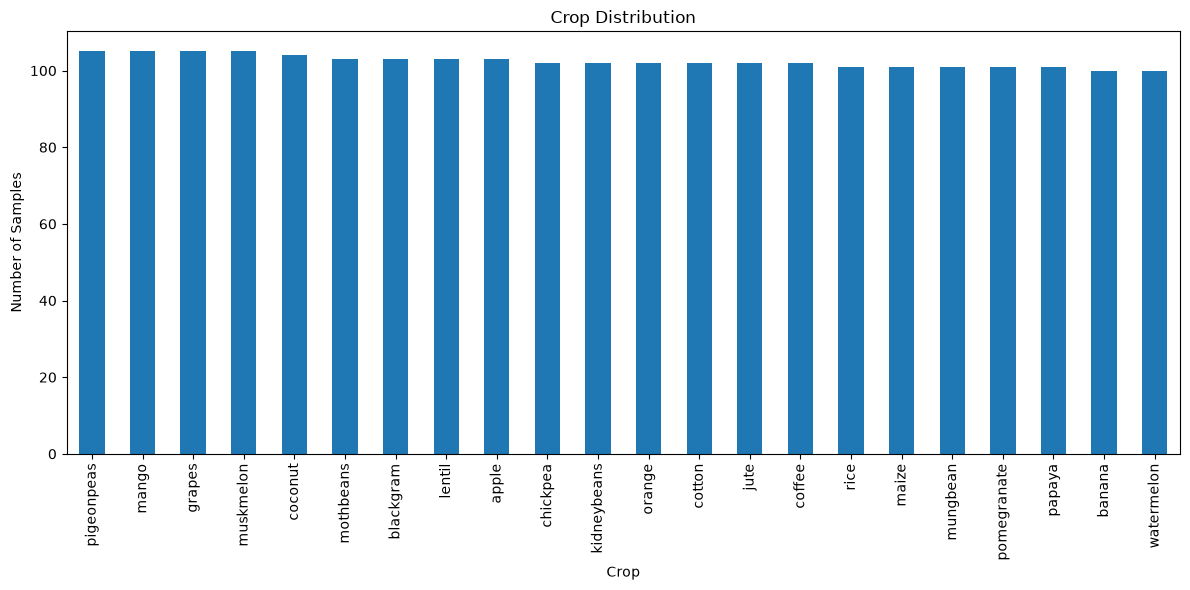

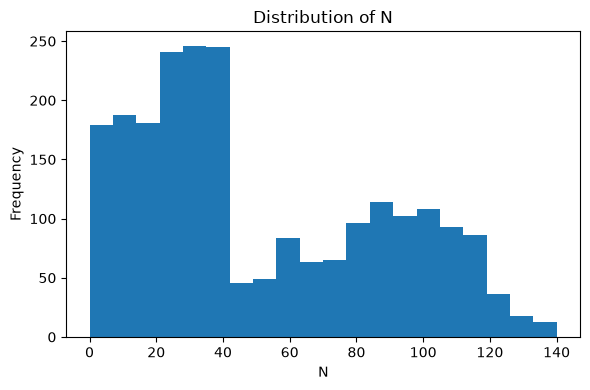

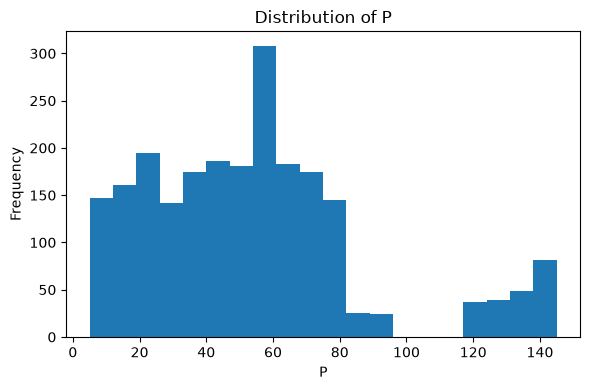

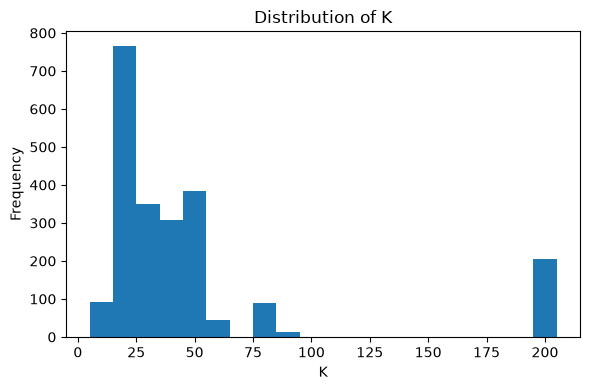

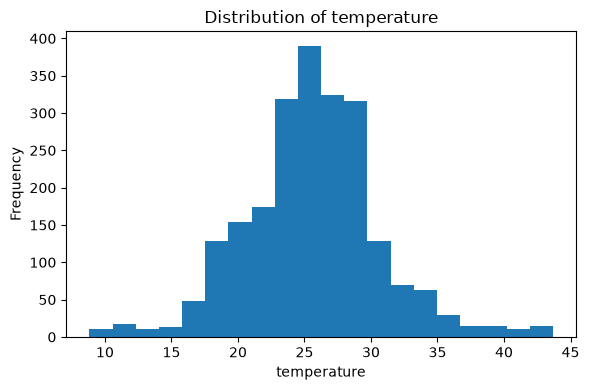

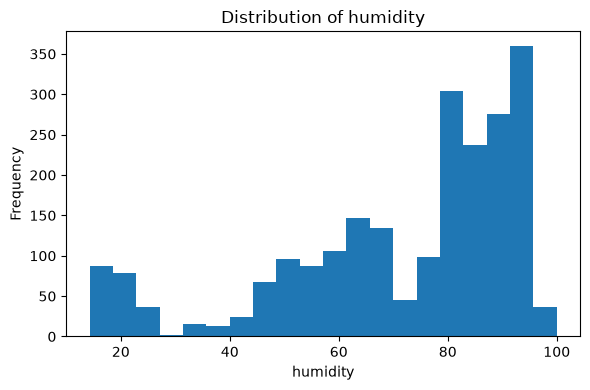

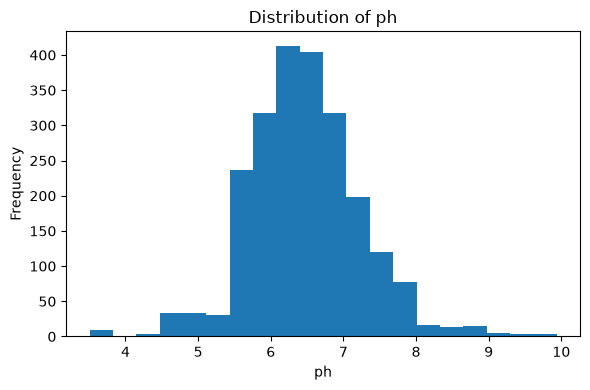

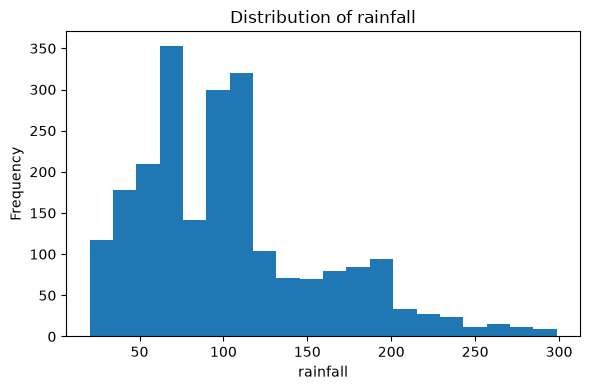


Correlation Matrix:
                    N         P         K  temperature  humidity        ph  \
N            1.000000 -0.228573 -0.139194     0.026730  0.191403  0.102453   
P           -0.228573  1.000000  0.729350    -0.127249 -0.114702 -0.135700   
K           -0.139194  0.729350  1.000000    -0.163632  0.190338 -0.170233   
temperature  0.026730 -0.127249 -0.163632     1.000000  0.200733 -0.020210   
humidity     0.191403 -0.114702  0.190338     0.200733  1.000000 -0.006785   
ph           0.102453 -0.135700 -0.170233    -0.020210 -0.006785  1.000000   
rainfall     0.053318 -0.062026 -0.055417    -0.030591  0.091213 -0.109915   

             rainfall  
N            0.053318  
P           -0.062026  
K           -0.055417  
temperature -0.030591  
humidity     0.091213  
ph          -0.109915  
rainfall     1.000000  


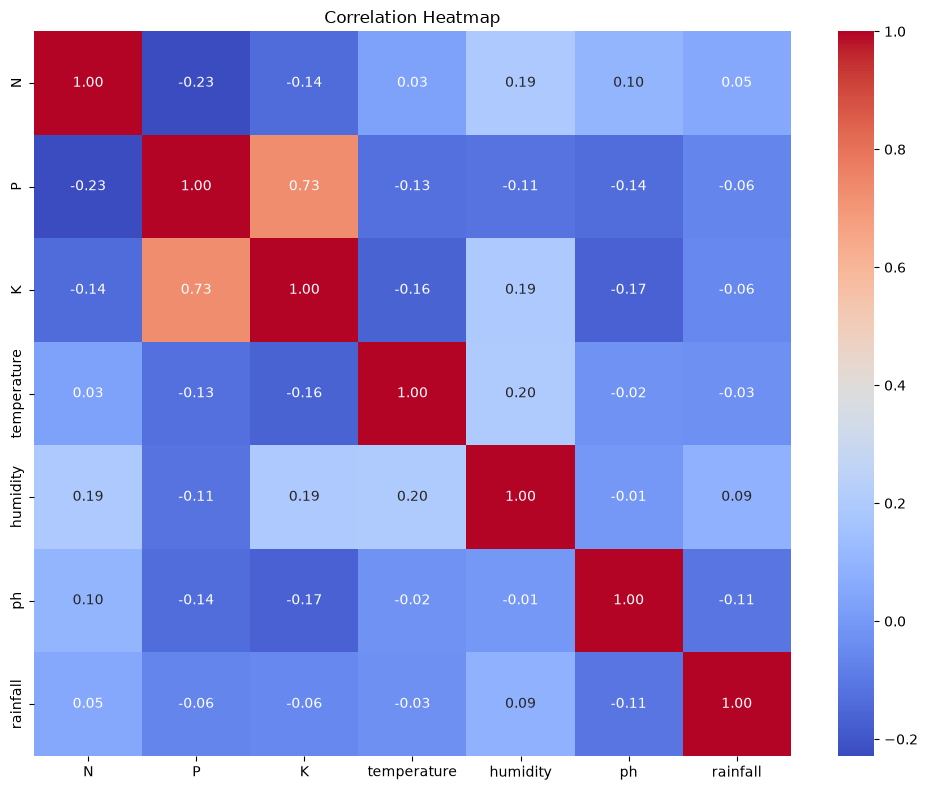

In [4]:
from Preprocessing.eda_correlation import run_eda

run_eda(df=df)

## Step 5: Export Processed Data

In [5]:
from Preprocessing.export_processed_data import run_export

run_export(df=df)

Processed dataset saved to: c:\Users\Acer\Desktop\AIML_CRP\Crop_Recommendation_System\Dataset\Processed\processed_crop_data.csv
Final shape: (2253, 8)
      N     P     K  temperature   humidity        ph    rainfall label
0  37.0  42.0  43.0    20.879744  82.002744  6.502985  202.935536  rice
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  226.655537  rice
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  263.964248  rice
3  74.0  35.0  40.0    26.491096  80.158363  6.980401  242.864034  rice
4  78.0  42.0  42.0    20.130175  81.604873  7.628473  262.717340  rice


'c:\\Users\\Acer\\Desktop\\AIML_CRP\\Crop_Recommendation_System\\Dataset\\Processed\\processed_crop_data.csv'

## Step 6: Display Processed Data

In [6]:
%run Notebooks/display_processed_data.ipynb

First few rows of the processed dataset:
      N     P     K  temperature   humidity        ph    rainfall label
0  37.0  42.0  43.0    20.879744  82.002744  6.502985  202.935536  rice
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  226.655537  rice
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  263.964248  rice
3  74.0  35.0  40.0    26.491096  80.158363  6.980401  242.864034  rice
4  78.0  42.0  42.0    20.130175  81.604873  7.628473  262.717340  rice
Processed Dataset Shape: (2253, 8)
Columns:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2253 non-null   float64
 1   P            2253 non-null   float64
 2   K            2253 non-null   float64
 3   temperature  2253 non-null   float64
 4   humidity     2253 no

## Step 7: Load the Trained Model

In [7]:
from Models.train_model import load_model

model, label_encoder, feature_names = load_model()

Model loaded from:         c:\Users\Acer\Desktop\AIML_CRP\Crop_Recommendation_System\Models\trained_model.pkl
Label encoder loaded from: c:\Users\Acer\Desktop\AIML_CRP\Crop_Recommendation_System\Models\label_encoder.pkl


## Step 8: Crop Recommendation — Final Prediction

In [10]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

print('Enter the soil and climate values to get a crop recommendation:')
N           = float(input('Enter Nitrogen value: '))
P           = float(input('Enter Phosphorus value: '))
K           = float(input('Enter Potassium value: '))
temperature = float(input('Enter Temperature: '))
humidity    = float(input('Enter Humidity: '))
while True:
        ph = float(input('Enter pH value (1-10): '))
        if 1 <= ph <= 10:
            break
        print('Invalid pH! Must be between 1 and 10.')
rainfall    = float(input('Enter Rainfall value: '))

user_input = [[N, P, K, temperature, humidity, ph, rainfall]]

prediction_encoded = model.predict(user_input)
predicted_crop = label_encoder.inverse_transform(prediction_encoded)

print('\nRecommended Crop:', predicted_crop[0])

Enter the soil and climate values to get a crop recommendation:

Recommended Crop: kidneybeans
